# Problemas de Estadística Descriptiva

## Ejercicio 1 – ¿Qué tan largos son los títulos de las películas?

En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:
- Calcular la longitud del título (en caracteres).
- Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
- Identificar los títulos más largos y más cortos.
- Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.


In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, mode

# Cargar dataset de IMDb
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [2]:
# Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título
df["title_length"] = df["title"].str.len()

df["title_length"]

0      24
1      13
2      22
3      15
4      12
       ..
974     7
975    27
976    47
977    11
978    11
Name: title_length, Length: 979, dtype: int64

In [3]:
# Calcula media, mediana y moda de la columna 'title_length'
media = df["title_length"].mean()
mediana = df["title_length"].median()
moda = mode(df["title_length"], keepdims=True)

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda.mode[0])

Media: 15.481103166496425
Mediana: 14.0
Moda: 12


In [4]:
# Calcula el rango, la varianza y la desviación estándar de 'title_length'
rango = df["title_length"].max() - df["title_length"].min()
varianza = df["title_length"].var()
desviacion = df["title_length"].std()

print("Rango:", rango)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)

Rango: 67
Varianza: 72.1067488840288
Desviación estándar: 8.491569282766807


In [5]:
# Calcula asimetría y curtosis de la columna 'title_length'
asimetria = skew(df["title_length"])
curt = kurtosis(df["title_length"])

print("Asimetría:", asimetria)
print("Curtosis:", curt)

Asimetría: 1.5229143965677572
Curtosis: 3.7867237597626007


In [6]:
# Imprime el título más corto y el título más largo según su longitud
titulo_corto = df.loc[df["title_length"].idxmin(), "title"]
titulo_largo = df.loc[df["title_length"].idxmax(), "title"]

print("Título más corto:", titulo_corto)
print("Título más largo:", titulo_largo)

Título más corto: M
Título más largo: Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb


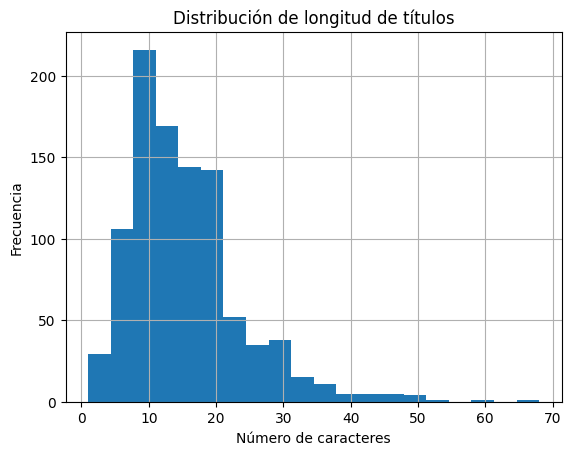

In [7]:
# grafica tus resultados
df["title_length"].hist(bins=20)

plt.title("Distribución de longitud de títulos")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")

plt.show()

---

## Ejercicio 2 – Cálculo manual de desviación estándar

En este ejercicio vas a calcular manualmente la desviación estándar, seleccionando cinco títulos reales del dataset de películas que cargaste antes.


In [8]:
# Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]
valores = df["title_length"].head(5).tolist()

print(valores)

[24, 13, 22, 15, 12]


In [9]:
# Calcula la media de los 5 valores
media = sum(valores) / len(valores)

print("Media:", media)

Media: 17.2


In [10]:
# Calcula las diferencias al cuadrado con respecto a la media
diferencias_cuadrado = [(x - media) ** 2 for x in valores]

print(diferencias_cuadrado)

[46.24000000000001, 17.639999999999993, 23.040000000000006, 4.839999999999997, 27.039999999999992]


In [11]:
# Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación
varianza = sum(diferencias_cuadrado) / len(diferencias_cuadrado)

desviacion_estandar = varianza ** 0.5

print("Varianza:", varianza)
print("Desviación estándar:", desviacion_estandar)

Varianza: 23.76
Desviación estándar: 4.874423042781577
